In [5]:
import pandas as pd
import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from textblob import TextBlob

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
df = pd.read_csv("/content/complaints.csv")

print(df.head())

   Unnamed: 0           product  \
0           0       credit_card   
1           1       credit_card   
2           2    retail_banking   
3           3  credit_reporting   
4           4  credit_reporting   

                                           narrative  
0  purchase order day shipping amount receive pro...  
1  forwarded message date tue subject please inve...  
2  forwarded message cc sent friday pdt subject f...  
3  payment history missing credit report speciali...  
4  payment history missing credit report made mis...  


In [6]:
stop_words = set(
    stopwords.words('english')
)

def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r'[^a-zA-Z ]',
        '',
        text
    )

    words = word_tokenize(text)

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df['Clean_Complaint'] = \
df['narrative'].apply(
    clean_text
)

In [7]:
print(
    df['product']
    .value_counts()
)

product
credit_reporting       67460
debt_collection        17515
mortgages_and_loans    15359
credit_card            13117
retail_banking         11342
Name: count, dtype: int64


In [8]:
def get_sentiment(text):

    polarity = TextBlob(
        text
    ).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

df['Sentiment'] = \
df['Clean_Complaint'].apply(
    get_sentiment
)

print(
    df['Sentiment']
    .value_counts()
)

Sentiment
Positive    58215
Negative    48888
Neutral     17690
Name: count, dtype: int64


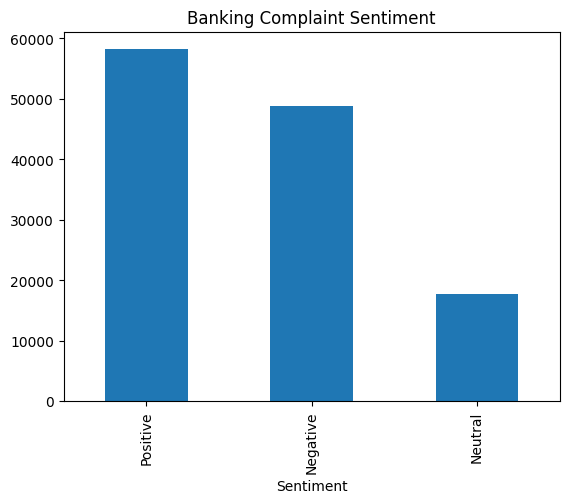

In [9]:
import matplotlib.pyplot as plt

df['Sentiment'] \
.value_counts() \
.plot(kind='bar')

plt.title(
    "Banking Complaint Sentiment"
)

plt.show()

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    max_features=10,
    stop_words='english'
)

X = vectorizer.fit_transform(
    df['Clean_Complaint']
)

print(
    vectorizer
    .get_feature_names_out()
)

['account' 'company' 'credit' 'day' 'information' 'loan' 'payment'
 'report' 'reporting' 'time']


In [11]:
print("Total Complaints:",
      len(df))

print("Categories:",
      df['product'].nunique())

print(
    "Most Common Category:",
    df['product']
    .value_counts()
    .idxmax()
)

Total Complaints: 124793
Categories: 5
Most Common Category: credit_reporting
